<a href="https://colab.research.google.com/github/kosar-am/finance-prediction-rnn/blob/main/notebooks/05_gru_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Stock Price Prediction using RNN, LSTM, and GRU

## 05 — GRU Model

In this notebook, a Gated Recurrent Unit (GRU) model is built and trained to predict Google stock prices using the preprocessed sequential dataset.

### Objectives

- Load and preprocess the dataset
- Build a GRU model
- Train the model
- Evaluate the model
- Visualize the training process
- Predict stock prices on the test set



## 📚 Import Required Libraries

In [15]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Setting Up Project Paths

In [16]:
RESULTS_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026/results"

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
PROJECT_PATH = "/content/drive/MyDrive/My-Project/finance-prediction-rnn-2026"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

In [19]:
from src.preprocessing import prepare_data

print("✅ Preprocessing module imported successfully.")

✅ Preprocessing module imported successfully.


## 📦 Data Preparation

In [20]:
# Load preprocessed data

X_train, X_test, y_train, y_test, scaler = prepare_data()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

[*********************100%***********************]  1 of 1 completed

X_train shape: (2152, 60, 1)
X_test shape : (493, 60, 1)
y_train shape: (2152, 1)
y_test shape : (493, 1)


## 🤖 Build the GRU Model

In [21]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(units=50, activation="tanh"),
    Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Compile the Model

In [22]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

## 🚀 Train the Model

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0192 - val_loss: 0.0056
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.7416e-04 - val_loss: 0.0024
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.4918e-04 - val_loss: 0.0026
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 2.3119e-04 - val_loss: 0.0025
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 2.2278e-04 - val_loss: 0.0028
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 2.1165e-04 - val_loss: 0.0022
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.1624e-04 - val_loss: 0.0026
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 2.0335e-04 - val_loss: 0.0033
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 1.9525e-04 - val_loss: 0.0024
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 1.9257e-04 - val_loss: 0.0030
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.8582e-04 - val_loss: 0.0041
Epoch 12/20
68/68 ━━━━━

## 📊 Visualizing the Results

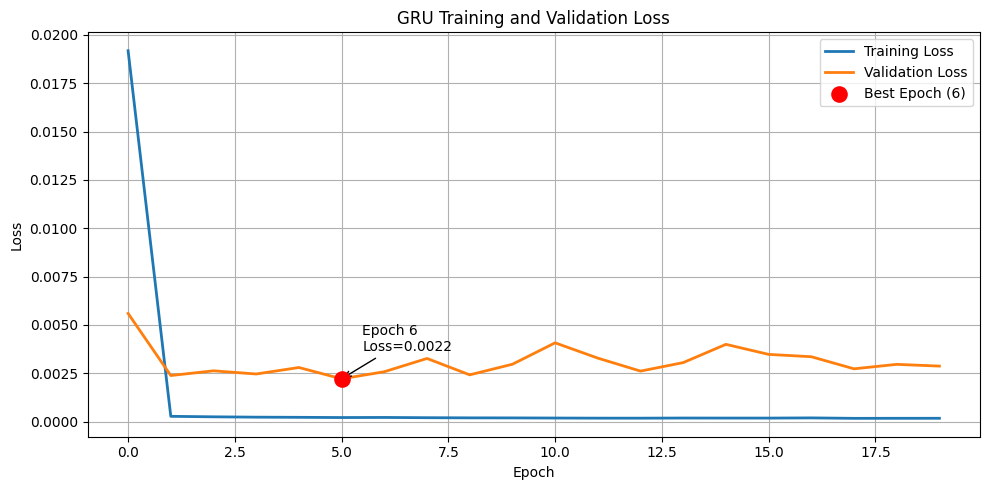

Best Epoch: 6
Lowest Validation Loss: 0.002214


In [24]:
# Find the best epoch based on the lowest validation loss

best_epoch = np.argmin(history.history["val_loss"])
best_val_loss = history.history["val_loss"][best_epoch]

plt.figure(figsize=(10, 5))

# Plot training and validation loss
plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

# Highlight the best epoch
plt.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=120,
    zorder=5,
    label=f"Best Epoch ({best_epoch + 1})"
)

plt.annotate(
    f"Epoch {best_epoch + 1}\nLoss={best_val_loss:.4f}",
    xy=(best_epoch, best_val_loss),
    xytext=(15, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/gru_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best Epoch: {best_epoch + 1}")
print(f"Lowest Validation Loss: {best_val_loss:.6f}")

### Analysis

The training history indicates that the GRU model converged rapidly during the first few epochs. Both the training and validation losses decreased significantly at the beginning of the training process, demonstrating that the model quickly learned the underlying temporal patterns in the stock price data.

The lowest validation loss was achieved at **epoch 6**, suggesting that this epoch provided the best balance between learning the training data and maintaining good generalization on unseen data. After this point, the training loss remained close to zero, while the validation loss fluctuated slightly without showing a consistent downward trend. This behavior suggests that the model began to fit the training data more closely, leading to a mild degree of overfitting.

Despite these fluctuations, the validation loss remained relatively stable throughout the remaining epochs, indicating that the GRU model maintained consistent predictive performance without severe degradation. Overall, the training process demonstrates that the GRU architecture successfully captured the sequential characteristics of the stock price series while achieving stable convergence.

## 📊 Evaluating the Model

In [25]:
y_pred = model.predict(X_test)

y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MAE : 4.3902
RMSE: 6.7019
R²  : 0.9768


### Actual vs Predicted Stock Prices

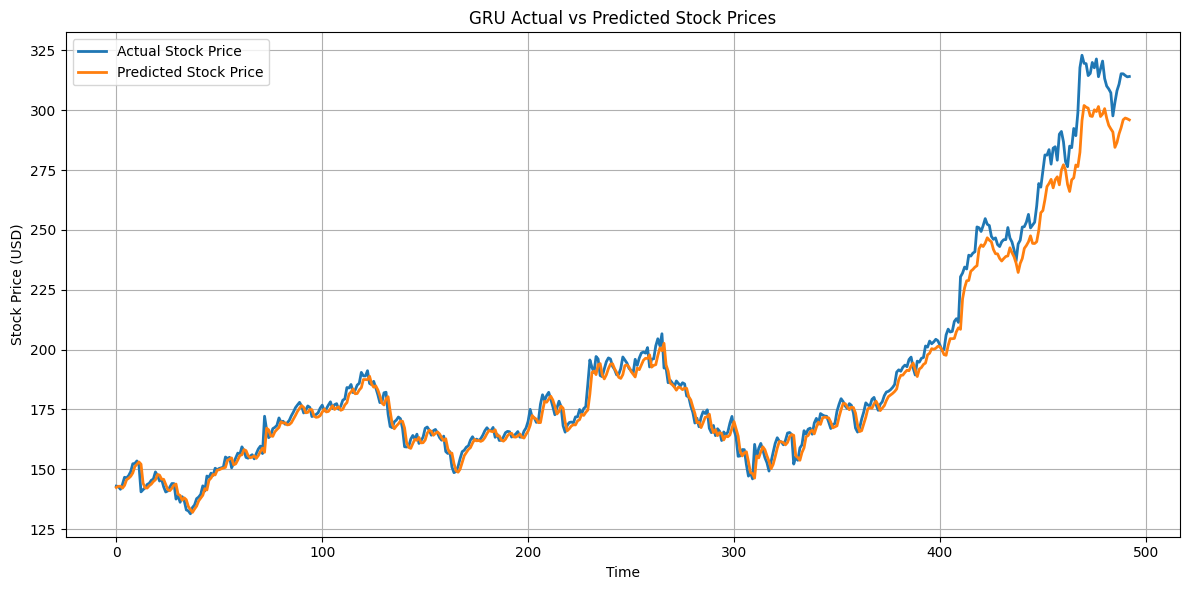

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual Stock Price",
    linewidth=2
)

plt.plot(
    y_pred_actual,
    label="Predicted Stock Price",
    linewidth=2
)

plt.title("GRU Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/gru_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The comparison between the actual and predicted stock prices demonstrates that the GRU model successfully captured the overall trend and temporal behavior of the Google stock price series. The predicted values closely follow the actual prices throughout most of the test period, indicating that the model effectively learned the underlying sequential patterns in the data.

The model performs particularly well during periods of relatively stable price movements, where the predicted curve almost overlaps with the actual observations. However, during periods of rapid price increases, especially near the end of the testing period, the predicted values tend to slightly underestimate the actual stock prices. This behavior is common in sequence forecasting models, as they generally produce smoother predictions and may not fully capture sudden market fluctuations.

Overall, the close agreement between the two curves suggests that the GRU model provides reliable forecasting performance while maintaining good generalization on unseen data. The small prediction errors observed during highly volatile periods indicate opportunities for further improvement through hyperparameter tuning, additional market features, or more advanced neural network architectures.

### Residual Plot

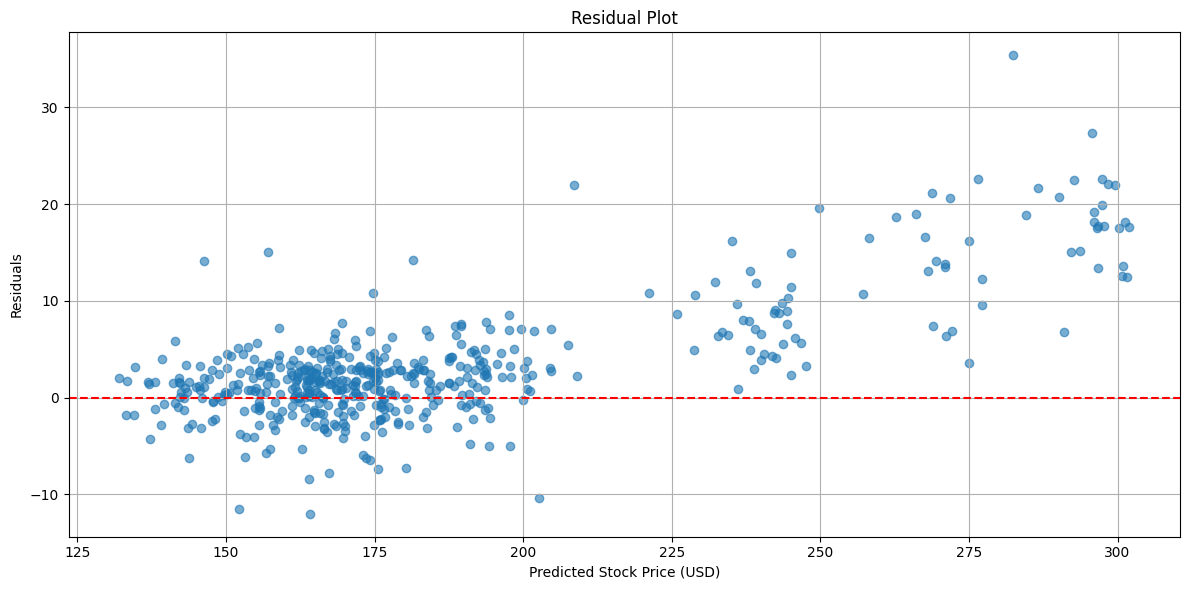

In [27]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(12, 6))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Stock Price (USD)")
plt.ylabel("Residuals")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_PATH}/gru_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analysis

The residual plot provides additional insight into the prediction errors of the GRU model. Most residuals are distributed close to the zero reference line, indicating that the model generally produces accurate predictions with relatively small errors across a large portion of the test dataset.

For lower and moderate stock prices, the residuals appear randomly scattered around zero without a clear systematic pattern, suggesting that the model does not exhibit significant bias in these price ranges. However, as the predicted stock price increases, the residuals become predominantly positive and their variability increases. This indicates that the model tends to **underestimate higher stock prices**, particularly during periods of strong upward market movements.

The increasing spread of residuals at larger predicted values also suggests that prediction uncertainty grows as market volatility increases. Despite this behavior, the absence of strong systematic patterns in most of the residual distribution indicates that the GRU model captures the underlying trend effectively while maintaining stable prediction performance across the majority of observations. Future improvements could focus on reducing errors during highly volatile periods by incorporating additional market indicators, optimizing hyperparameters, or exploring more advanced deep learning architectures.

In [28]:
metrics = pd.DataFrame({
    "Model": ["GRU"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    f"{RESULTS_PATH}/gru_metrics.csv",
    index=False
)

metrics

,Model,MAE,RMSE,R2
0,GRU,4.390188,6.701887,0.976817
